In [1]:
# 08 - Prediction
# Loads the best model saved by 07_Model_Comparison.ipynb and uses it to:
#   1. Generate predictions for every respondent, alongside their actual choice
#   2. Show where the model is right and where it's wrong (with context)
#   3. Predict for a brand-new, hypothetical respondent
#   4. Save all predictions to a CSV
# Note: this model was already refit on ALL 186 labeled rows in notebook 07,so the in-sample accuracy shown here will look better than the honest
# cross-validated estimate,  it's for illustrating individual predictions, not a performance claim. See 10_Testing.ipynb for a clean, unseen-data
# evaluation, and cite the CV macro-F1 from notebook 07 for real performance.
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

bundle = joblib.load('data/processed/models/best_model.pkl')
model = bundle['model']
model_name = bundle['model_name']
label_encoder = bundle['label_encoder']
feature_cols = bundle['feature_columns']
print(f"Loaded model: {model_name}")
print(f"Cross-validated macro-F1 (from notebook 07): {bundle['cv_macro_f1']:.3f}")


Loaded model: Random Forest
Cross-validated macro-F1 (from notebook 07): 0.387


In [2]:
# Load the feature table and re-encode identically to training 
feature_table = pd.read_csv('data/processed/features/Engineered_Features.csv')
categorical_cols = ['Gender', 'Occupation', 'Residence_Type']
non_feature_cols = ['Respondent_ID', 'Most_Used_Tool']
raw_feature_cols = [c for c in feature_table.columns if c not in non_feature_cols]

X_full = pd.get_dummies(feature_table[raw_feature_cols], columns=categorical_cols, drop_first=True)
X_full = X_full.reindex(columns=feature_cols, fill_value=0)
y_full = feature_table['Most_Used_Tool']
print(f"Feature matrix for prediction: {X_full.shape}")


Feature matrix for prediction: (186, 26)


In [3]:
# Predict for every respondent 
if model_name == 'XGBoost':
    pred_enc = model.predict(X_full)
    predictions = label_encoder.inverse_transform(pred_enc)
else:
    predictions = model.predict(X_full)

results = feature_table[['Respondent_ID']].copy()
results['Actual_Tool'] = y_full.values
results['Predicted_Tool'] = predictions
results['Correct'] = results['Actual_Tool'] == results['Predicted_Tool']
print(f"Overall accuracy on all labeled respondents (in-sample, see note above): {results['Correct'].mean():.3f}")
results.head(10)


Overall accuracy on all labeled respondents (in-sample, see note above): 0.844


,Respondent_ID,Actual_Tool,Predicted_Tool,Correct
0,R001,Claude,Claude,True
1,R002,ChatGPT,ChatGPT,True
2,R003,Claude,Claude,True
3,R004,Claude,Claude,True
4,R005,ChatGPT,Gemini,False
5,R006,ChatGPT,ChatGPT,True
6,R007,Claude,Claude,True
7,R008,Claude,Claude,True
8,R009,ChatGPT,ChatGPT,True
9,R010,Gemini,Gemini,True


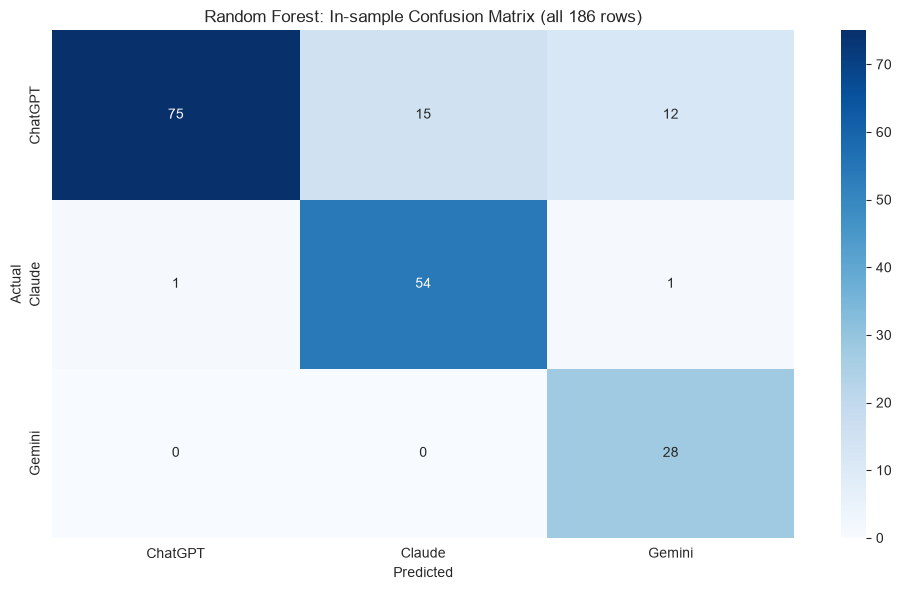

In [5]:
# Diagram: confusion matrix, in-sample predictions 
labels = sorted(y_full.unique())
cm = confusion_matrix(y_full, predictions, labels=labels)
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f'{model_name}: In-sample Confusion Matrix (all 186 rows)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


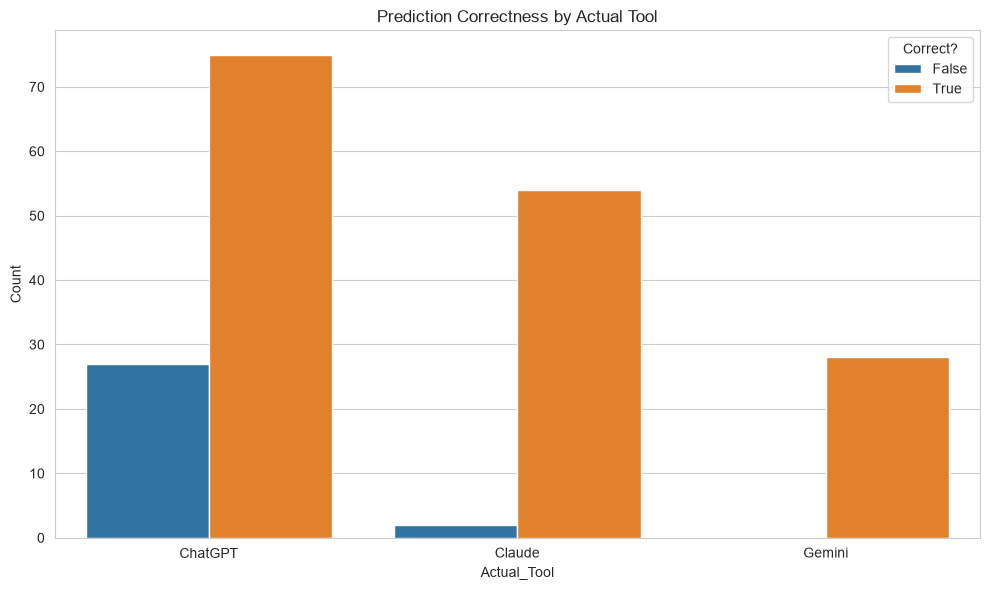

Actual_Tool
ChatGPT    0.74
Claude     0.96
Gemini     1.00
Name: Correct, dtype: float64


In [6]:
# Where does the model get it right vs wrong? 
plt.figure(figsize=(10, 6))
sns.countplot(data=results, x='Actual_Tool', hue='Correct', order=results['Actual_Tool'].value_counts().index)
plt.title('Prediction Correctness by Actual Tool')
plt.ylabel('Count')
plt.legend(title='Correct?')
plt.tight_layout()
plt.show()
print(results.groupby('Actual_Tool')['Correct'].mean().round(2))


In [7]:
# A few example misclassifications 
wrong = results[~results['Correct']].merge(
    feature_table[['Respondent_ID', 'Age_Group_Code', 'Occupation', 'Usage_Frequency_Code']],
    on='Respondent_ID', how='left'
)
wrong.head(10)


,Respondent_ID,Actual_Tool,Predicted_Tool,Correct,Age_Group_Code,Occupation,Usage_Frequency_Code
0,R005,ChatGPT,Gemini,False,2,Student,4.0
1,R016,ChatGPT,Claude,False,2,Ophthalmic assistant,6.0
2,R017,ChatGPT,Gemini,False,2,Student,6.0
3,R026,ChatGPT,Claude,False,2,Student,6.0
4,R042,Claude,Gemini,False,2,Student,6.0
5,R044,ChatGPT,Gemini,False,2,Student,4.0
6,R045,ChatGPT,Gemini,False,1,Student,5.0
7,R051,ChatGPT,Gemini,False,3,Private-sector Employee,6.0
8,R056,ChatGPT,Claude,False,2,IT professional,6.0
9,R058,ChatGPT,Claude,False,2,IT professional,6.0


In [8]:
# Predict for a new, hypothetical respondent 
# Demonstrates how to use the saved model on someone who isn't in the survey at all  build one row with the same feature columns and call .predict().
new_respondent_raw = {
    'Age_Group_Code': 2,          # 18-24
    'Gender': 'Female',
    'Occupation': 'Student',
    'Residence_Type': 'Urban',
    'Usage_Frequency_Code': 5,    # once a day
    'Satisfaction_Code': 4,       # Satisfied
    'Num_Tools_Known': 3,
    'Num_Usage_Purposes': 4,
    'Num_Usage_Contexts': 2,
    'Num_Concerns': 1,
    'Is_Heavy_User': 1,
    'Has_Multiple_Concerns': 0,
    'Knows_Multiple_Tools': 1,
}
new_df = pd.DataFrame([new_respondent_raw])
new_encoded = pd.get_dummies(new_df, columns=['Gender', 'Occupation', 'Residence_Type'])
new_encoded = new_encoded.reindex(columns=feature_cols, fill_value=0)

if model_name == 'XGBoost':
    pred = label_encoder.inverse_transform(model.predict(new_encoded))[0]
    proba = model.predict_proba(new_encoded)[0]
    classes = label_encoder.inverse_transform(np.arange(len(proba)))
else:
    pred = model.predict(new_encoded)[0]
    proba = model.predict_proba(new_encoded)[0]
    classes = model.classes_

print(f"Predicted most-used tool: {pred}")
print()
print("Class probabilities:")
for cls, p in sorted(zip(classes, proba), key=lambda x: -x[1]):
    print(f"  {cls}: {p:.2f}")


Predicted most-used tool: Claude

Class probabilities:
  Claude: 0.47
  ChatGPT: 0.29
  Gemini: 0.24


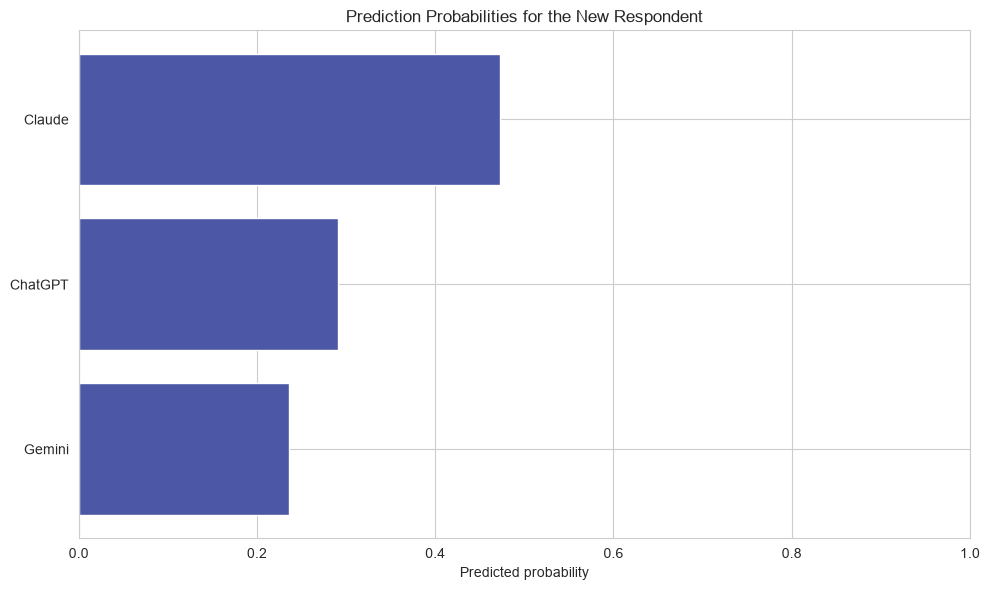

In [10]:
#  Diagram: probability distribution for the new respondent 
probs = sorted(zip(classes, proba), key=lambda x: -x[1])
plt.figure(figsize=(10, 6))
plt.barh([c for c, p in probs][::-1], [p for c, p in probs][::-1], color='#4C58A6')
plt.xlabel('Predicted probability')
plt.title('Prediction Probabilities for the New Respondent')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


In [11]:
# Save predictions 
out_path = 'data/processed/Predictions.csv'
results.to_csv(out_path, index=False)
print(f"Saved: {out_path}")


Saved: data/processed/Predictions.csv
